# Binary Classification of Machine Failures - Makine Arızalarının İkili Sınıflandırılması

<img src="https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQc9GtjWD62M-R_WkYze4tfM7Fz_-TAE2Pu25CVj5pQDQ&s=10">

Bu projenin amacı, makinelere ait operasyonel verileri kullanarak bir makinenin arızalanıp arızalanmayacağını önceden tahmin edebilen makine öğrenmesi modelleri geliştirmektir. Elde edilen veriler üzerinde çeşitli sınıflandırma algoritmaları uygulanarak modellerin performansları karşılaştırılmış ve en başarılı yöntem belirlenmeye çalışılmıştır. Böylece olası arızaların önceden tespit edilmesi, bakım süreçlerinin optimize edilmesi ve üretim kayıplarının azaltılması hedeflenmiştir.

### Sütun Açıklamaları

**id**: Veri setindeki her kayda ait benzersiz kimlik numarasıdır.

**Product ID**: Ürünün veya makinenin kimlik kodudur.

**Type**: Ürün tipi bilgisini gösterir.

**Air temperature [K]**: Makinenin bulunduğu ortamın hava sıcaklığını Kelvin cinsinden ifade eder.

**Process temperature [K]**: Üretim sürecindeki sıcaklığı Kelvin cinsinden gösterir.

**Rotational speed [rpm]**: Makinenin dönme hızını dakika başına devir sayısı olarak ifade eder.

**Torque [Nm]**: Makinenin çalışma sırasında ürettiği tork değerini gösterir.

**Tool wear [min]**: Takımın kullanım süresini ve aşınma miktarını dakika cinsinden ifade eder.

**Machine failure**: Makinenin arızalanıp arızalanmadığını gösteren hedef değişkendir.

**TWF (Tool Wear Failure)**: Takım aşınması nedeniyle oluşan arızayı gösterir.

**HDF (Heat Dissipation Failure)**: Isı dağılımındaki yetersizlikten kaynaklanan arızayı gösterir.

**PWF (Power Failure)**: Güç kaynaklı arızaları ifade eder.

**OSF (Overstrain Failure)**: Aşırı yüklenme sonucu meydana gelen arızaları gösterir.

**RNF (Random Failure)**: Rastgele meydana gelen arızaları ifade eder.

### Veri seti linki

https://www.kaggle.com/competitions/playground-series-s3e17/data

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/playground-series-s3e17/sample_submission.csv
/kaggle/input/competitions/playground-series-s3e17/train.csv
/kaggle/input/competitions/playground-series-s3e17/test.csv


In [3]:
# Veri işleme
import pandas as pd
import numpy as np

# Görselleştirme
import matplotlib.pyplot as plt
import seaborn as sns

# Veri ön işleme
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Sınıflandırma Modelleri
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from sklearn.svm import SVC

# Performans Metrikleri
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Uyarıları gizleme (isteğe bağlı)
import warnings
warnings.filterwarnings("ignore")

In [4]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/competitions/playground-series-s3e17/sample_submission.csv
/kaggle/input/competitions/playground-series-s3e17/train.csv
/kaggle/input/competitions/playground-series-s3e17/test.csv


In [5]:
import pandas as pd

train = pd.read_csv("/kaggle/input/competitions/playground-series-s3e17/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s3e17/test.csv")

print("Train:", train.shape)
print("Test :", test.shape)

Train: (136429, 14)
Test : (90954, 13)


In [7]:
train.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


In [9]:
train.columns

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [10]:
train.describe()

,id,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000
mean,68214.000000,299.862776,309.941070,1520.331110,40.348643,104.408901,0.015744,0.001554,0.005160,0.002397,0.003958,0.002258
std,39383.804275,1.862247,1.385173,138.736632,8.502229,63.965040,0.124486,0.039389,0.071649,0.048899,0.062789,0.047461
min,0.000000,295.300000,305.800000,1181.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34107.000000,298.300000,308.700000,1432.000000,34.600000,48.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,68214.000000,300.000000,310.000000,1493.000000,40.400000,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,102321.000000,301.200000,310.900000,1580.000000,46.100000,159.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,136428.000000,304.400000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Product ID               136429 non-null  object 
 2   Type                     136429 non-null  object 
 3   Air temperature [K]      136429 non-null  float64
 4   Process temperature [K]  136429 non-null  float64
 5   Rotational speed [rpm]   136429 non-null  int64  
 6   Torque [Nm]              136429 non-null  float64
 7   Tool wear [min]          136429 non-null  int64  
 8   Machine failure          136429 non-null  int64  
 9   TWF                      136429 non-null  int64  
 10  HDF                      136429 non-null  int64  
 11  PWF                      136429 non-null  int64  
 12  OSF                      136429 non-null  int64  
 13  RNF                      136429 non-null  int64  
dtypes: f

In [12]:
train.isnull().sum()

id                         0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [13]:
train.select_dtypes(include="object").columns

Index(['Product ID', 'Type'], dtype='object')

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train["Type"] = le.fit_transform(train["Type"])
test["Type"] = le.transform(test["Type"])

train["Type"].head()

0    1
1    2
2    1
3    1
4    2
Name: Type, dtype: int64

In [15]:
le.classes_

array(['H', 'L', 'M'], dtype=object)

In [16]:
train = train.drop("Product ID", axis=1)
test = test.drop("Product ID", axis=1)

In [17]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Type                     136429 non-null  int64  
 2   Air temperature [K]      136429 non-null  float64
 3   Process temperature [K]  136429 non-null  float64
 4   Rotational speed [rpm]   136429 non-null  int64  
 5   Torque [Nm]              136429 non-null  float64
 6   Tool wear [min]          136429 non-null  int64  
 7   Machine failure          136429 non-null  int64  
 8   TWF                      136429 non-null  int64  
 9   HDF                      136429 non-null  int64  
 10  PWF                      136429 non-null  int64  
 11  OSF                      136429 non-null  int64  
 12  RNF                      136429 non-null  int64  
dtypes: float64(3), int64(10)
memory usage: 13.5 MB


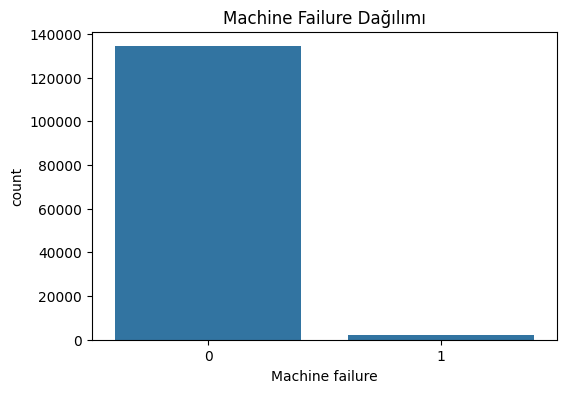

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=train, x="Machine failure")
plt.title("Machine Failure Dağılımı")
plt.show()

Grafik incelendiğinde, arızalanmayan makine sayısının arızalanan makine sayısından çok daha fazla olduğu görülmektedir. Bu durum veri setinin dengesiz bir sınıf dağılımına sahip olduğunu göstermektedir. Bu nedenle model performansı değerlendirilirken yalnızca doğruluk oranına değil, Precision, Recall ve F1-Score metriklerine de dikkat edilmelidir!!!

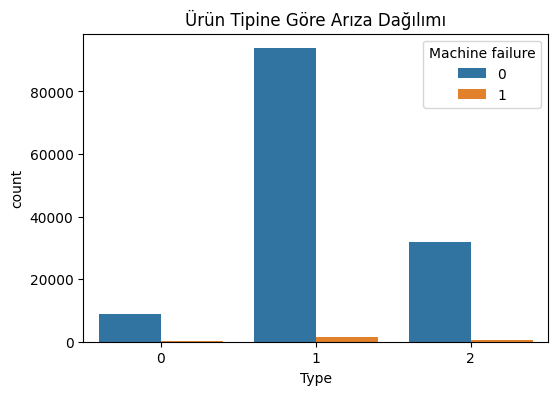

In [28]:
plt.figure(figsize=(6,4))
sns.countplot(data=train, x="Type", hue="Machine failure")
plt.title("Ürün Tipine Göre Arıza Dağılımı")
plt.show()

Grafik incelendiğinde, tüm ürün tiplerinde arızalanmayan makine sayısının arızalanan makine sayısından oldukça fazla olduğu görülmektedir. Bununla birlikte en fazla gözlem ve arıza sayısı Type = 1 (L tipi) ürünlerde görülmektedir. Ancak bu durumun temel nedeni L tipi ürünlerin veri setinde daha fazla bulunmasıdır. Ürün tipi ile arıza durumu arasında belirli farklılıklar bulunsa da, tek başına ürün tipinin arızayı açıklamak için yeterli olmadığı söylenebilir.

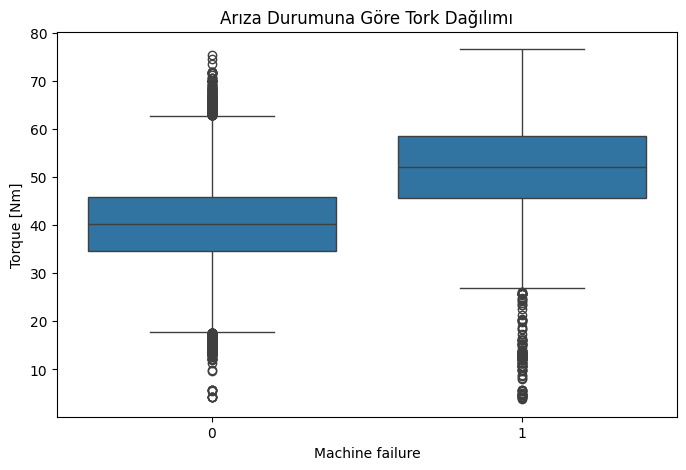

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(data=train, x="Machine failure", y="Torque [Nm]")
plt.title("Arıza Durumuna Göre Tork Dağılımı")
plt.show()

Grafik incelendiğinde, arızalanan makinelerin tork değerlerinin genel olarak arızalanmayan makinelere göre daha yüksek olduğu görülmektedir. Özellikle arızalı makinelerde medyan tork değerinin daha yüksek olması, tork arttıkça arıza riskinin de artabileceğini göstermektedir. Bu durum, Torque [Nm] değişkeninin makine arızalarının tahmin edilmesinde önemli bir özellik olabileceğine işaret etmekted

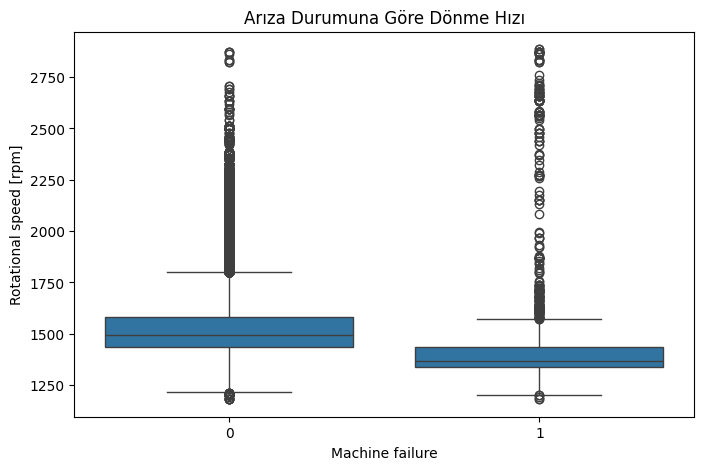

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(data=train, x="Machine failure", y="Rotational speed [rpm]")
plt.title("Arıza Durumuna Göre Dönme Hızı")
plt.show()

Grafik incelendiğinde, arızalanan makinelerin dönme hızlarının genel olarak arızalanmayan makinelere göre daha düşük olduğu görülmektedir. Arızalı makinelerde medyan dönme hızının daha düşük olması, düşük dönme hızlarının arıza oluşumu ile ilişkili olabileceğini göstermektedir. Bu durum, Rotational speed [rpm] değişkeninin makine arızalarının tahmin edilmesinde önemli bir faktör olabileceğine işaret etmektedir.

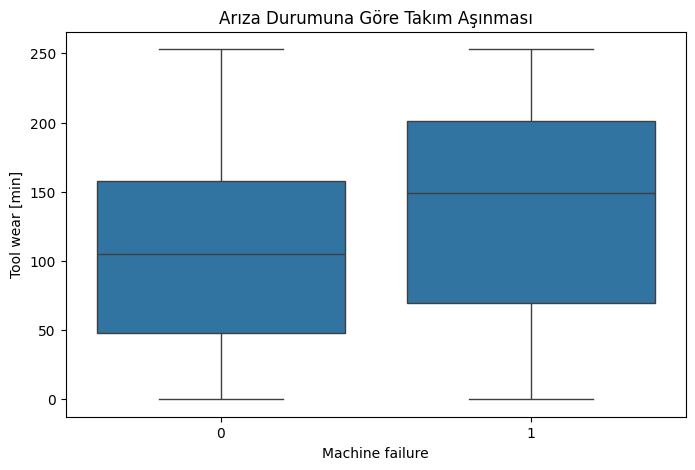

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(data=train, x="Machine failure", y="Tool wear [min]")
plt.title("Arıza Durumuna Göre Takım Aşınması")
plt.show()

Grafik incelendiğinde, arızalanan makinelerde takım aşınma sürelerinin arızalanmayan makinelere göre daha yüksek olduğu görülmektedir. Özellikle medyan değerin ve orta %50'lik veri aralığının daha yüksek seviyelerde bulunması, takım aşınması arttıkça makine arızası oluşma olasılığının da arttığını göstermektedir. Bu nedenle Tool wear [min] değişkeni makine arızalarının tahmin edilmesinde önemli bir faktör olarak değerlendirilebilir.

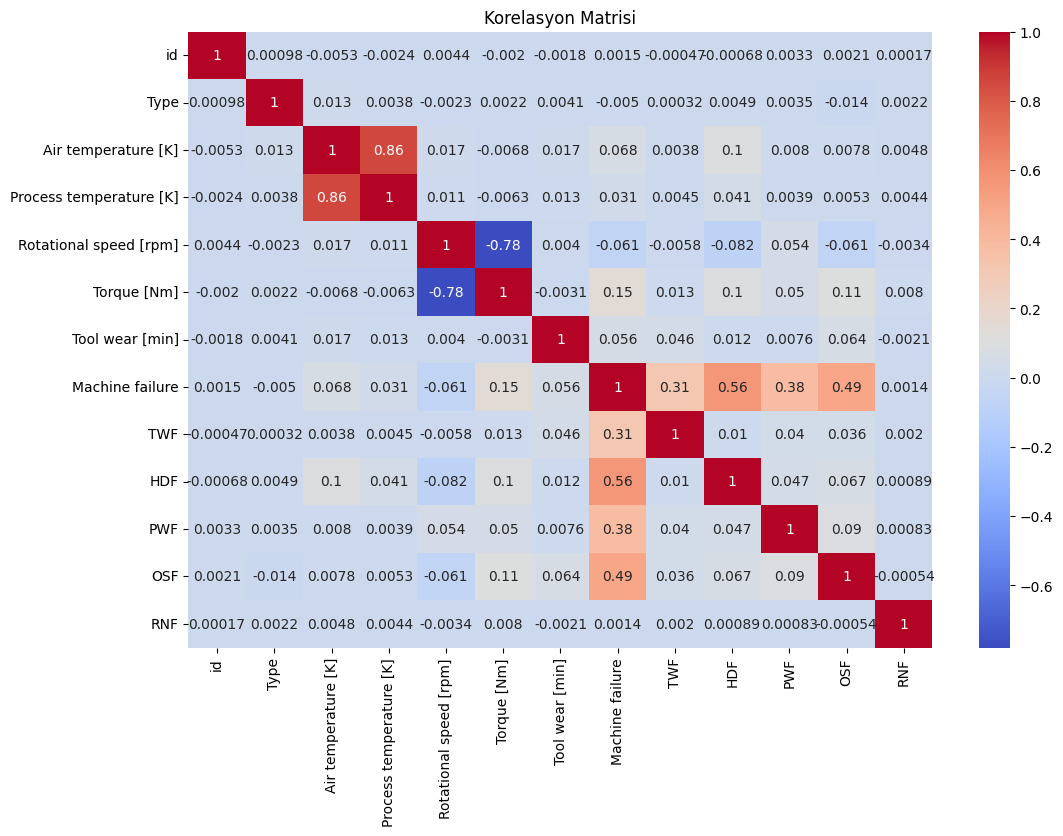

In [32]:
plt.figure(figsize=(12,8))
sns.heatmap(train.corr(), annot=True, cmap="coolwarm")
plt.title("Korelasyon Matrisi")
plt.show()

Korelasyon matrisi incelendiğinde, hava sıcaklığı ile proses sıcaklığı arasında güçlü pozitif, dönme hızı ile tork arasında ise güçlü negatif ilişki olduğu görülmektedir. Makine arızası değişkeni ile en yüksek ilişki arıza türlerini gösteren sütunlarda bulunurken, operasyonel değişkenler arasında en dikkat çekici ilişki tork ve takım aşınması değişkenlerinde gözlemlenmiştir. Bu sonuçlar, makine arızalarının tek bir değişkenden ziyade birden fazla faktörün birlikte etkisiyle oluştuğunu göstermektedir.

In [18]:
x = train.drop("Machine failure", axis=1)
y = train["Machine failure"]

In [19]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42
)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

model_lr = lr.fit(x_train, y_train)

tahmin_lr = model_lr.predict(x_test)

accuracy_score(y_test, tahmin_lr)

0.995638789122627

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt = DecisionTreeClassifier(random_state=42)

model_dt = dt.fit(x_train, y_train)

tahmin_dt = model_dt.predict(x_test)

accuracy_score(y_test, tahmin_dt)

0.9921205013560067

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(random_state=42)

model_rf = rf.fit(x_train, y_train)

tahmin_rf = model_rf.predict(x_test)

accuracy_score(y_test, tahmin_rf)

0.9961518727552591

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import pandas as pd


def algo_test_classification(x, y):
    
    LR = LogisticRegression(max_iter=1000)
    NB = GaussianNB()
    GB = GradientBoostingClassifier(random_state=42)
    ET = ExtraTreesClassifier(random_state=42)
    DT = DecisionTreeClassifier(random_state=42)
    
    algos = [LR, NB, GB, ET, DT]
    
    algo_names = [
        'Logistic Regression',
        'Naive Bayes',
        'Gradient Boosting',
        'Extra Trees',
        'Decision Tree'
    ]
    
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=42
    )
    
    accuracy = []
    precision = []
    recall = []
    f1 = []
    
    result = pd.DataFrame(
        columns=['Accuracy', 'Precision', 'Recall', 'F1_Score'],
        index=algo_names
    )
    
    for algo in algos:
        p = algo.fit(x_train, y_train).predict(x_test)
        
        accuracy.append(accuracy_score(y_test, p))
        precision.append(precision_score(y_test, p))
        recall.append(recall_score(y_test, p))
        f1.append(f1_score(y_test, p))
    
    result['Accuracy'] = accuracy
    result['Precision'] = precision
    result['Recall'] = recall
    result['F1_Score'] = f1
    
    return result.sort_values('F1_Score', ascending=False)

In [26]:
algo_test_classification(x, y)

,Accuracy,Precision,Recall,F1_Score
Gradient Boosting,0.996079,0.979710,0.771689,0.863346
Extra Trees,0.996079,0.982507,0.769406,0.862996
Logistic Regression,0.995639,0.990769,0.735160,0.844037
Decision Tree,0.992121,0.742919,0.778539,0.760312
Naive Bayes,0.978450,0.209302,0.123288,0.155172


## Sonuç

Bu çalışmada makine arızası tahmini için beş farklı sınıflandırma algoritması uygulanmış ve performansları Accuracy, Precision, Recall ve F1-Score metrikleri kullanılarak değerlendirilmiştir. Sonuçlar incelendiğinde Gradient Boosting modeli %99.61 doğruluk oranı ve 0.8633 F1-Score değeri ile en başarılı model olarak öne çıkmıştır. Gradient Boosting modelini çok yakın sonuçlarla Extra Trees ve Logistic Regression modelleri takip etmiştir. Decision Tree modeli kabul edilebilir performans göstermesine rağmen diğer gelişmiş modellerin gerisinde kalmıştır. Naive Bayes modeli ise özellikle Recall ve F1-Score değerlerinin düşük olması nedeniyle bu veri seti için uygun bir yöntem olmadığını göstermiştir. Genel olarak değerlendirildiğinde, makine arızalarının tahmin edilmesinde Gradient Boosting modelinin en başarılı ve dengeli sonuçları verdiği görülmüştür.